In [2]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for plots
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('../../data/laptop_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [4]:
#Data Cleaning

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')


In [6]:
df = df.drop(['Unnamed: 0'], axis=1)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [7]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [8]:
print(df.duplicated().sum())
print(df.shape)

29
(1303, 11)


In [9]:
df= df.drop_duplicates()
df.shape

(1274, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   object 
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   object 
 10  Price             1274 non-null   float64
dtypes: float64(2), object(9)
memory usage: 119.4+ KB


In [11]:
df['Ram'] = df['Ram'].str.replace('GB','')
df['Weight'] = df['Weight'].str.replace('kg','')

df['Ram'] = df['Ram'].astype('int32')
df['Weight'] = df['Weight'].astype('float32')

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int32  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float32
 10  Price             1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 109.5+ KB


In [13]:
df.describe()

,Inches,Ram,Weight,Price
count,1274.000000,1274.000000,1274.000000,1274.000000
mean,15.022449,8.444270,2.040401,60503.185074
std,1.429940,5.098291,0.669444,37333.222977
min,10.100000,2.000000,0.690000,9270.720000
25%,14.000000,4.000000,1.500000,32495.605200
50%,15.600000,8.000000,2.040000,52693.920000
75%,15.600000,8.000000,2.310000,79773.480000
max,18.400000,64.000000,4.700000,324954.720000


In [ ]:
#Price distribution

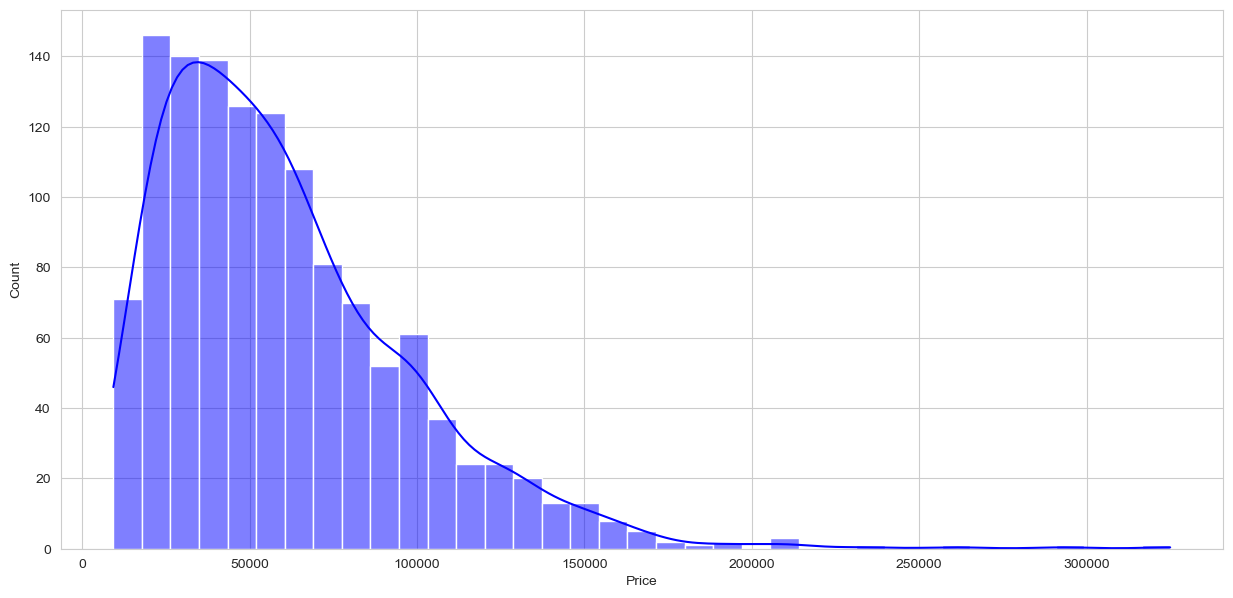

In [15]:
plt.figure(figsize=(15,7))
sns.histplot(df['Price'], color='blue',kde=True)
plt.show()

In [ ]:
#countplot for categorical variables

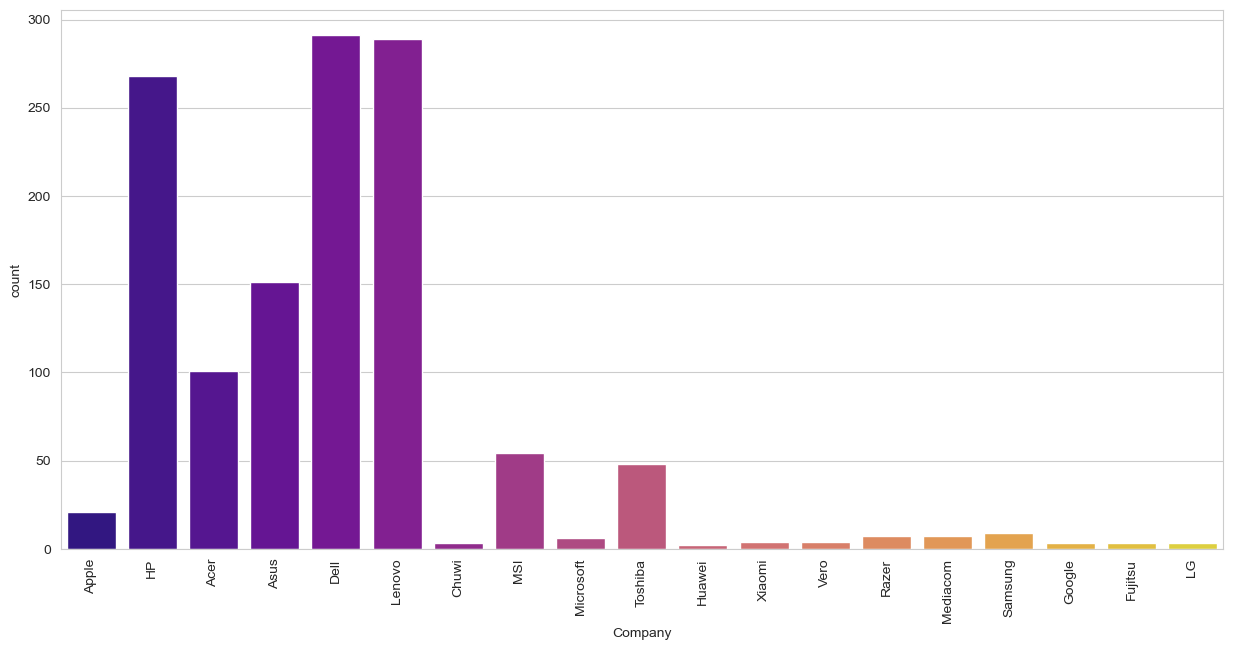

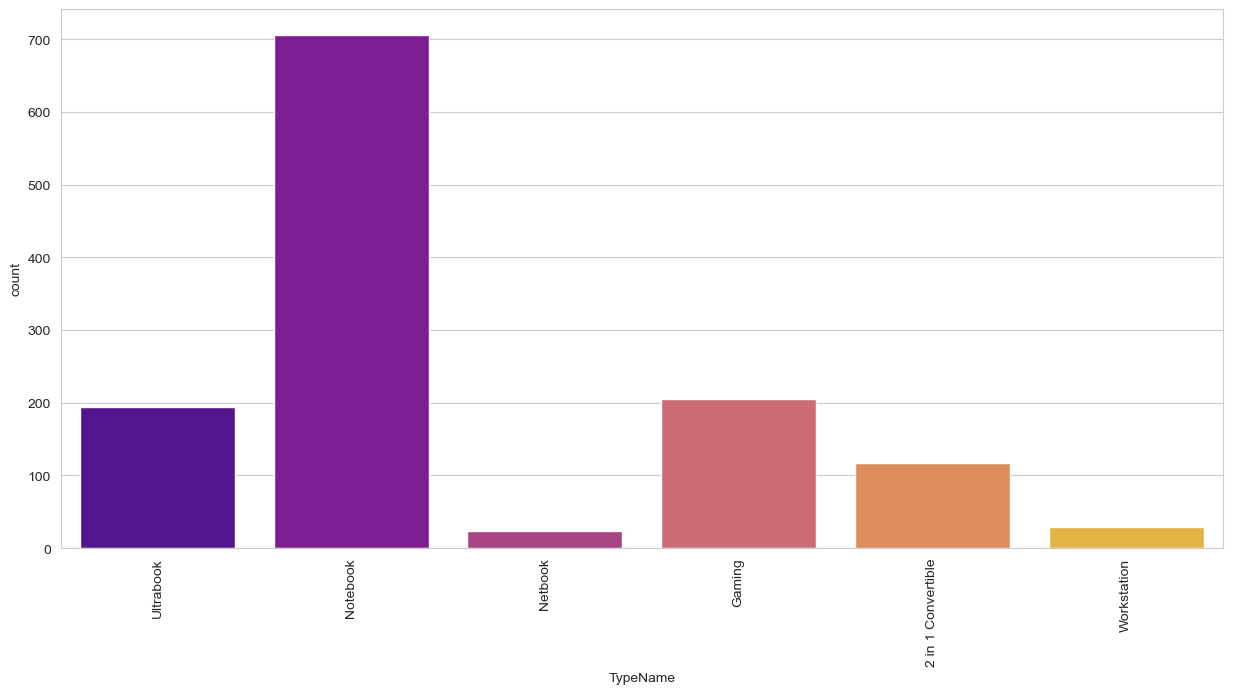

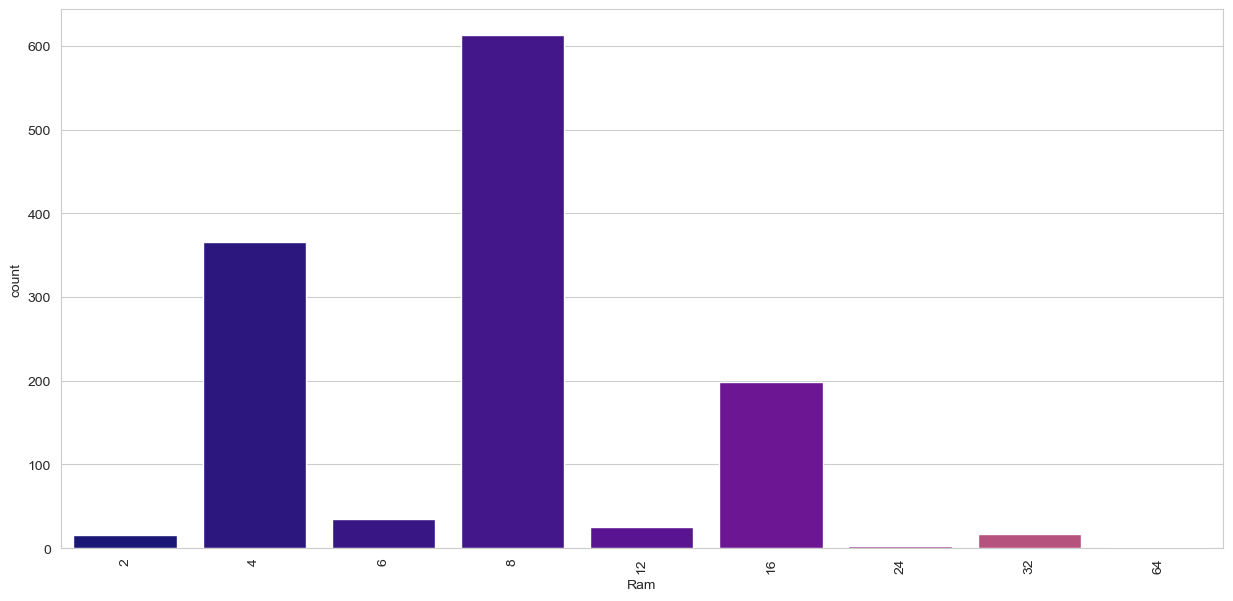

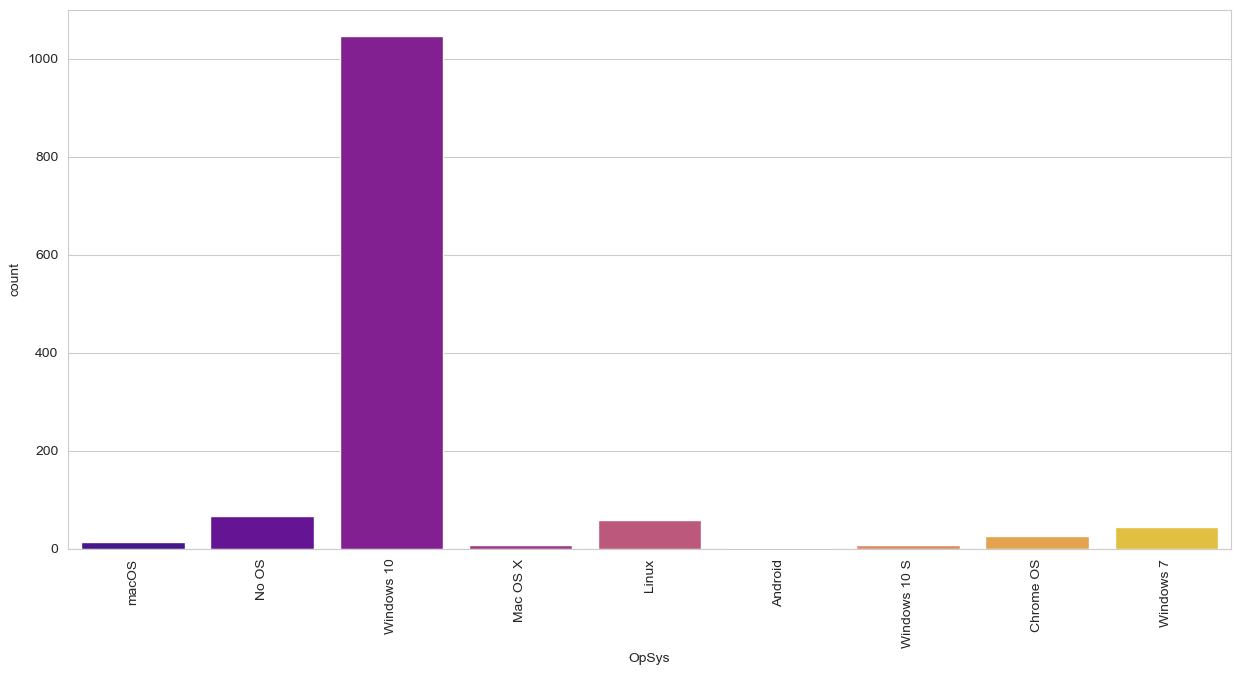

In [17]:
def drawplot(col):
    plt.figure(figsize=(15,7))
    sns.countplot(x=df[col], hue=df[col], palette='plasma', legend=False)
    plt.xticks(rotation='vertical')

toview = ['Company','TypeName','Ram','OpSys']
for col in toview:
    drawplot(col)

In [ ]:
#Average price for each brand

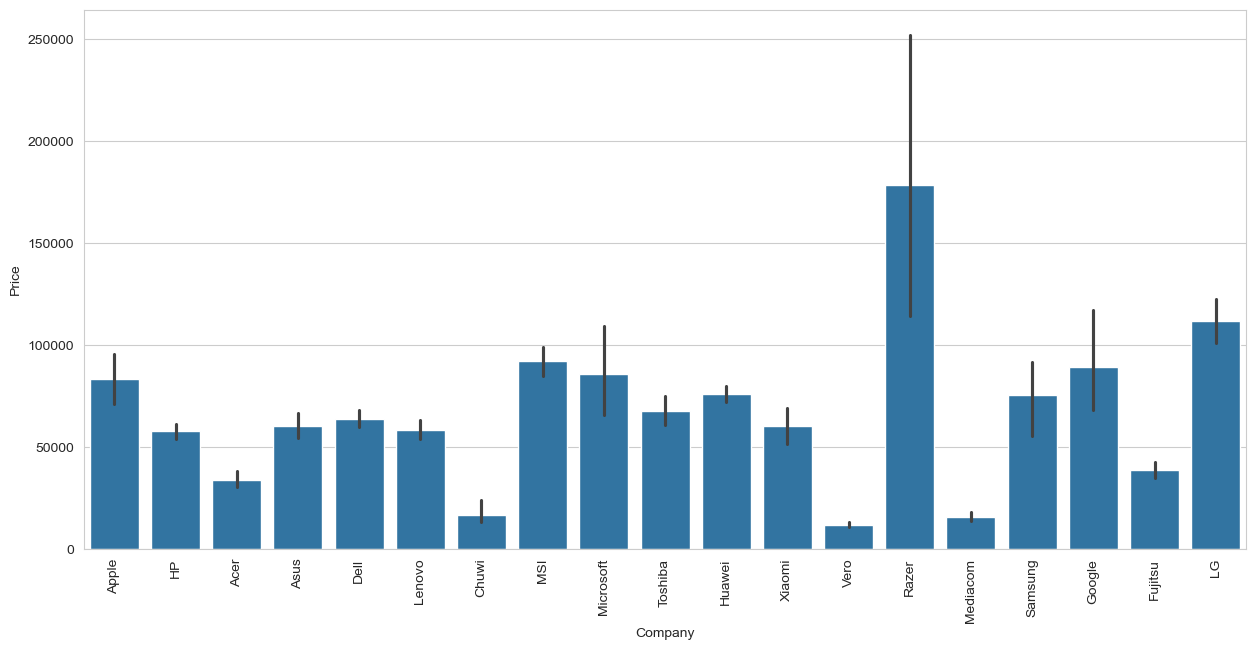

In [15]:
plt.figure(figsize=(15,7))
sns.barplot(x= df['Company'],y=df['Price'])
plt.xticks(rotation = 'vertical')
plt.show()

In [ ]:
#price variation on each laptop type

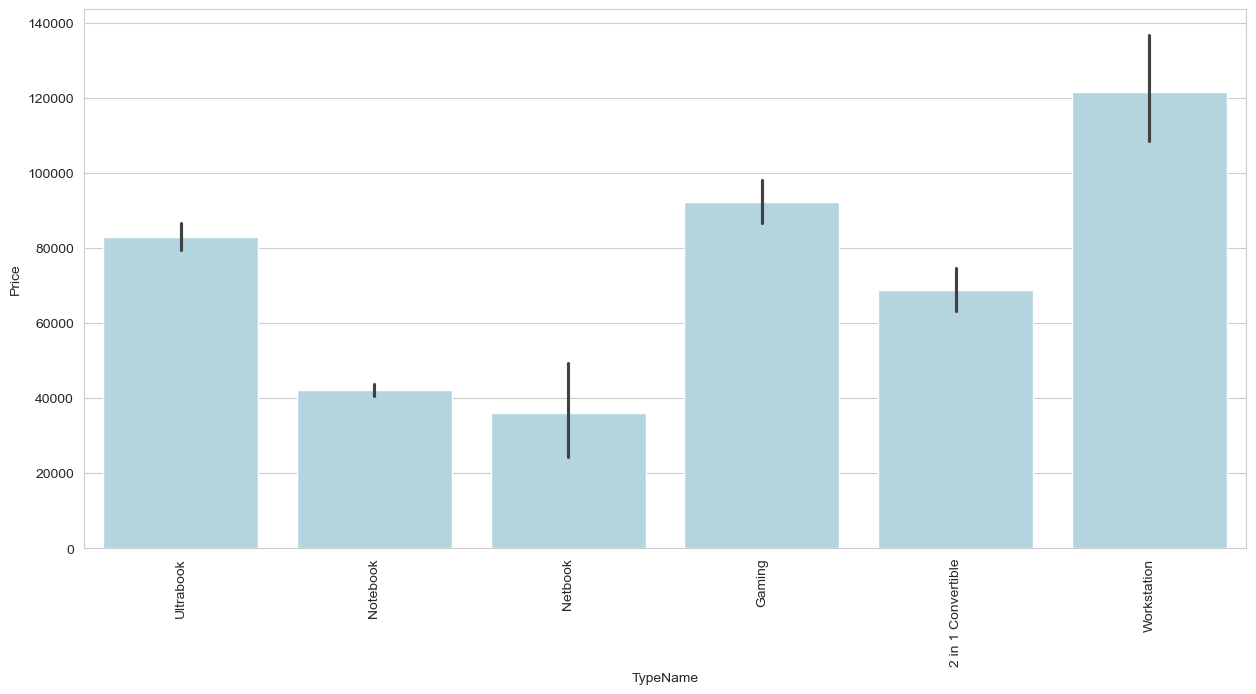

In [18]:
plt.figure(figsize=(15,7))
sns.barplot(x= df['TypeName'], y=df['Price'],color='lightblue')
plt.xticks(rotation = 'vertical')
plt.show()

In [ ]:
#price variation for different inches of laptops

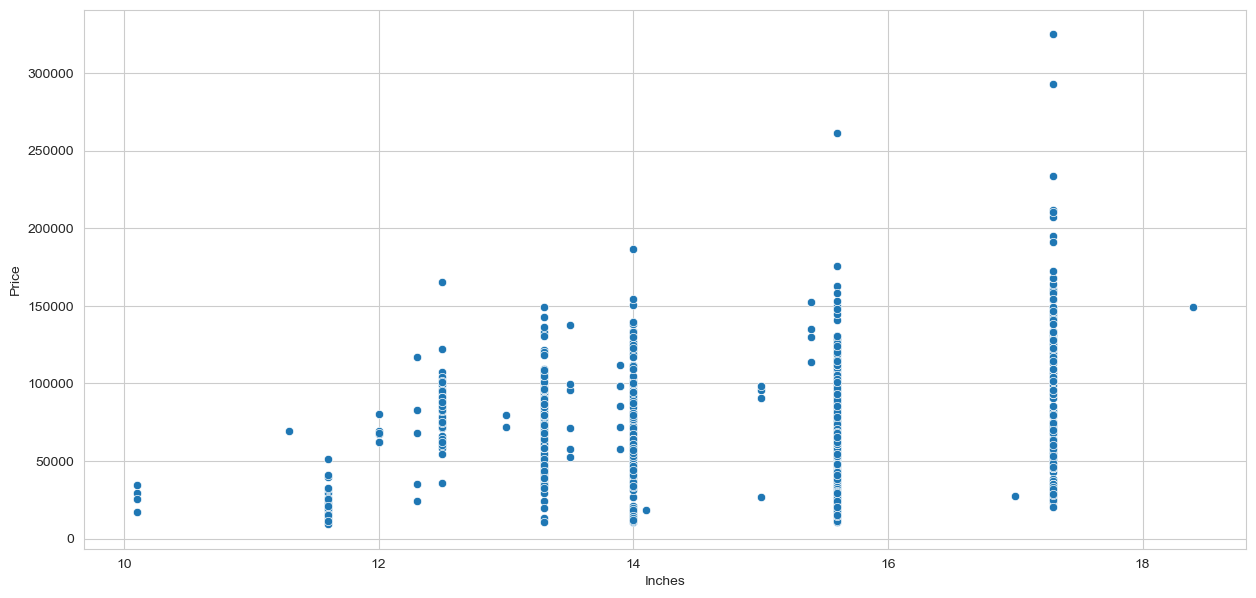

In [19]:
plt.figure(figsize=(15,7))
sns.scatterplot(x= df['Inches'], y= df['Price'])
plt.show()

In [ ]:
#-------Analysis Data------------

In [ ]:
#CPU Analysis

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int32  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float32
 10  Price             1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 109.5+ KB


In [21]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz     190
Intel Core i7 7700HQ 2.8GHz    146
Intel Core i7 7500U 2.7GHz     132
Intel Core i7 8550U 1.8GHz      73
Intel Core i5 8250U 1.6GHz      72
                              ... 
Intel Core M M3-6Y30 0.9GHz      1
AMD A9-Series 9420 2.9GHz        1
Intel Core i5 2.9GHz             1
AMD A6-Series 7310 2GHz          1
AMD A9-Series 9410 2.9GHz        1
Name: count, Length: 118, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int32  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float32
 10  Price             1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 109.5+ KB


In [23]:
df['CPU'] = df['Cpu'].apply(lambda text:" ".join(text.split()[:3]))
df.head(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,CPU
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5
5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows 10,2.10,21312.0000,AMD A9-Series 9420
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04,114017.6016,Intel Core i7
7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,61735.5360,Intel Core i5
8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows 10,1.30,79653.6000,Intel Core i7
9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.60,41025.6000,Intel Core i5


In [24]:
def processortype(text):
    if text== 'Intel Core i7' or text=='Intel Core i5' or text=='Intel Core i3':
        return text
    else:
        if text.split()[0]=='Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD'


df['CPU']= df['CPU'].apply(lambda text:processortype(text))
df.head()
        

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,CPU
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5


In [25]:
df.drop(columns=['Cpu'], inplace=True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,CPU
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5


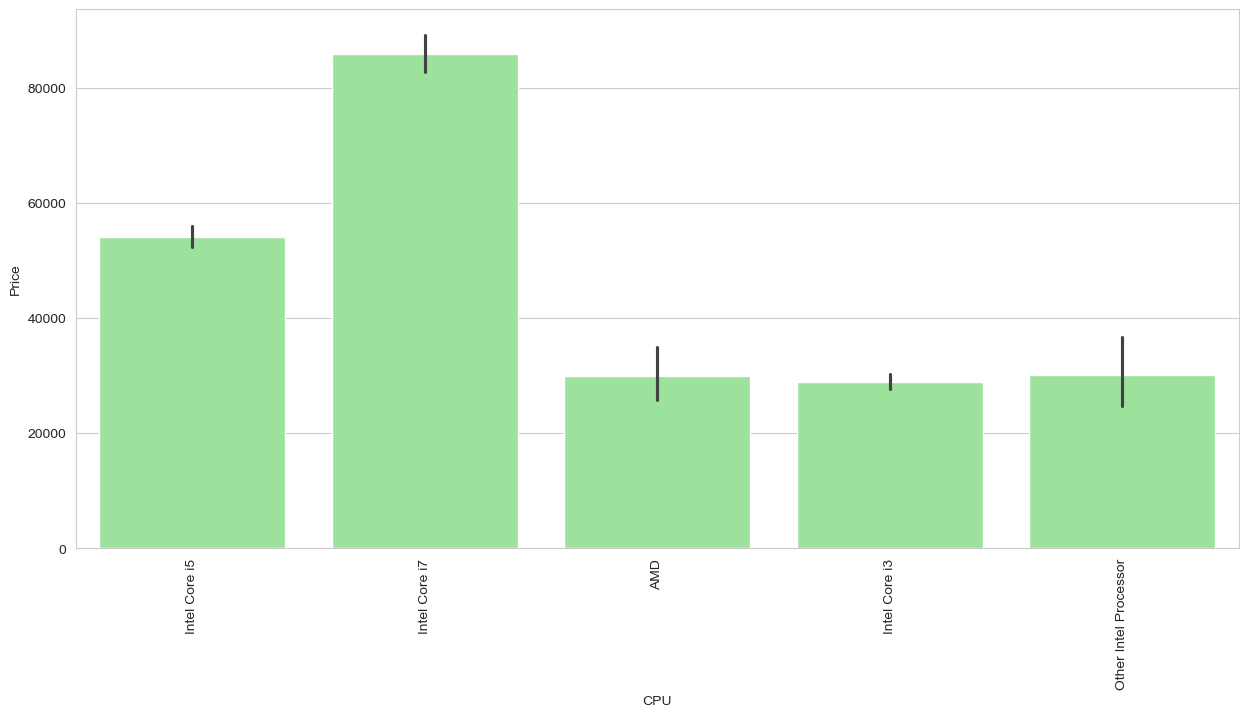

In [26]:
plt.figure(figsize=(15,7))
sns.barplot(x=df['CPU'],y=df['Price'],color='lightgreen')
plt.xticks(rotation= 'vertical')
plt.show()

In [ ]:
#Memory Analysis

In [27]:
df['Memory'].iloc[:1][0]

'128GB SSD'

In [28]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          215
500GB HDD                        123
512GB SSD                        114
128GB SSD +  1TB HDD              94
128GB SSD                         74
256GB SSD +  1TB HDD              73
32GB Flash Storage                36
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           14
64GB Flash Storage                13
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
16GB Flash Storage                 7
1.0TB Hybrid                       7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [29]:
df['Memory'] = df['Memory'].astype(str).replace('.0','',regex = True)
df['Memory'] = df['Memory'].str.replace('GB','')
df['Memory'] = df['Memory'].str.replace('TB','000')
newdf = df['Memory'].str.split("+",n = 1,expand = True)
newdf

,0,1
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1269,0 HDD,None
1270,128 SSD,None
1271,512 SSD,None
1272,64 Flash Storage,None


In [30]:
df['first'] = newdf[0]
df['first'] = df['first'].str.strip()
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,CPU,first
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5,128 SSD
1,Apple,Ultrabook,13.3,1440x900,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5,128 Flash Storage
2,HP,Notebook,15.6,Full HD 1920x1080,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5,256 SSD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7,512 SSD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5,256 SSD


In [31]:
def applychanges(value):
    
    df['Layer1'+value] = df['first'].apply(lambda x:1 if value in x else 0)
    
    
listtoapply = ['HDD','SSD','Hybrid','FlashStorage']    
for value in listtoapply:
    applychanges(value)
    
    
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,CPU,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1FlashStorage
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5,128 SSD,0,1,0,0
1,Apple,Ultrabook,13.3,1440x900,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5,128 Flash Storage,0,0,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5,256 SSD,0,1,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7,512 SSD,0,1,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5,256 SSD,0,1,0,0


In [32]:
df['first'] = df['first'].str.replace(r'\D','', regex=True)
df['first'].value_counts()

first
256     508
1000    240
128     175
512     136
0       123
32       43
2000     16
64       15
16       10
1         5
8         2
2         1
Name: count, dtype: int64

In [33]:
df['Second'] = newdf[1]
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,CPU,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1FlashStorage,Second
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5,128,0,1,0,0,None
1,Apple,Ultrabook,13.3,1440x900,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5,128,0,0,0,0,None
2,HP,Notebook,15.6,Full HD 1920x1080,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5,256,0,1,0,0,None
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7,512,0,1,0,0,None
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5,256,0,1,0,0,None


In [34]:
def applychanges1(value):
    
    df['Layer2'+value] = df['Second'].apply(lambda x:1 if value in x else 0)
    
    
listtoapply1 = ['HDD','SSD','Hybrid','FlashStorage']
df['Second'] = df['Second'].fillna("0")
for value in listtoapply1:
    applychanges1(value)

In [35]:
df['Second'] = df['Second'].str.replace(r'\D','',regex= True)
df['Second'].value_counts()

Second
0       1068
1000     187
2000      15
256        3
512        1
Name: count, dtype: int64

In [36]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,...,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1FlashStorage,Second,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2FlashStorage
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,...,128,0,1,0,0,0,0,0,0,0
1,Apple,Ultrabook,13.3,1440x900,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,...,128,0,0,0,0,0,0,0,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,...,256,0,1,0,0,0,0,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,...,512,0,1,0,0,0,0,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,...,256,0,1,0,0,0,0,0,0,0


In [37]:
df["HDD"]=(df["first"]*df["Layer1HDD"]+df["Second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["Second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["Second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1FlashStorage"]+df["Second"]*df["Layer2FlashStorage"])

In [38]:
df.drop(columns=['first', 'Second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1FlashStorage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2FlashStorage'],inplace=True)

In [39]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,Price,CPU,HDD,SSD,Hybrid,Flash_Storage
603,MSI,Gaming,17.3,Full HD 1920x1080,16,128 SSD + 1000 HDD,Nvidia GeForce GTX 970M,Windows 10,4.14,117162.7200,Intel Core i7,1000,128,,
992,Lenovo,Notebook,15.6,1366x768,4,128 SSD,Intel HD Graphics 500,No OS,1.90,14418.6336,Other Intel Processor,,128,,
711,Dell,Notebook,14.0,Full HD 1920x1080,8,256 SSD,Nvidia GeForce 930MX,Linux,1.64,58021.9200,Intel Core i5,,256,,
72,Dell,Notebook,15.6,Full HD 1920x1080,8,256 SSD,AMD Radeon 530,Windows 10,2.20,46353.6000,Intel Core i7,,256,,
804,Dell,Netbook,11.6,1366x768,4,128 SSD,Intel HD Graphics 505,Windows 10,1.63,39640.3200,Other Intel Processor,,128,,


In [40]:
df.drop(columns=['Memory'],inplace=True)
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,OpSys,Weight,Price,CPU,HDD,SSD,Hybrid,Flash_Storage
1231,Razer,Gaming,14.0,Full HD 1920x1080,16,Nvidia GeForce GTX 1060,Windows 10,1.95,186426.7200,Intel Core i7,,1000,,
150,Dell,Gaming,15.6,Full HD 1920x1080,16,Nvidia GeForce GTX 1050,Windows 10,2.56,66560.5728,Intel Core i7,,512,,
664,MSI,Gaming,17.3,Full HD 1920x1080,8,Nvidia GeForce GTX 1060,Windows 10,2.70,79215.1056,Intel Core i7,1000,128,,
242,Asus,Notebook,17.3,Full HD 1920x1080,8,Nvidia GeForce GTX 950M,No OS,2.69,47365.9200,Intel Core i7,1000,128,,
952,Toshiba,Notebook,13.3,Full HD 1920x1080,8,Intel HD Graphics 520,Windows 7,1.20,77788.8000,Intel Core i5,,256,,


In [41]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Ram', 'Gpu',
       'OpSys', 'Weight', 'Price', 'CPU', 'HDD', 'SSD', 'Hybrid',
       'Flash_Storage'],
      dtype='object')

In [42]:
df.drop(columns = ['Hybrid','Flash_Storage'],inplace= True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,OpSys,Weight,Price,CPU,HDD,SSD
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5,,128
1,Apple,Ultrabook,13.3,1440x900,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5,,
2,HP,Notebook,15.6,Full HD 1920x1080,8,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5,,256
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7,,512
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5,,256


In [ ]:
#GPU Analysis

In [43]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      279
Intel HD Graphics 520      181
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [44]:
df['GPU'] = df['Gpu'].apply(lambda text:" ".join(text.split()[:1]))
df.head(10)

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,OpSys,Weight,Price,CPU,HDD,SSD,GPU
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel Core i5,,128,Intel
1,Apple,Ultrabook,13.3,1440x900,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel Core i5,,,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,8,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel Core i5,,256,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel Core i7,,512,AMD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel Core i5,,256,Intel
5,Acer,Notebook,15.6,1366x768,4,AMD Radeon R5,Windows 10,2.10,21312.0000,AMD,0,,AMD
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,Intel Iris Pro Graphics,Mac OS X,2.04,114017.6016,Intel Core i7,,,Intel
7,Apple,Ultrabook,13.3,1440x900,8,Intel HD Graphics 6000,macOS,1.34,61735.5360,Intel Core i5,,,Intel
8,Asus,Ultrabook,14.0,Full HD 1920x1080,16,Nvidia GeForce MX150,Windows 10,1.30,79653.6000,Intel Core i7,,512,Nvidia
9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,8,Intel UHD Graphics 620,Windows 10,1.60,41025.6000,Intel Core i5,,256,Intel


In [45]:
df.drop(columns=['Gpu'], inplace= True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel


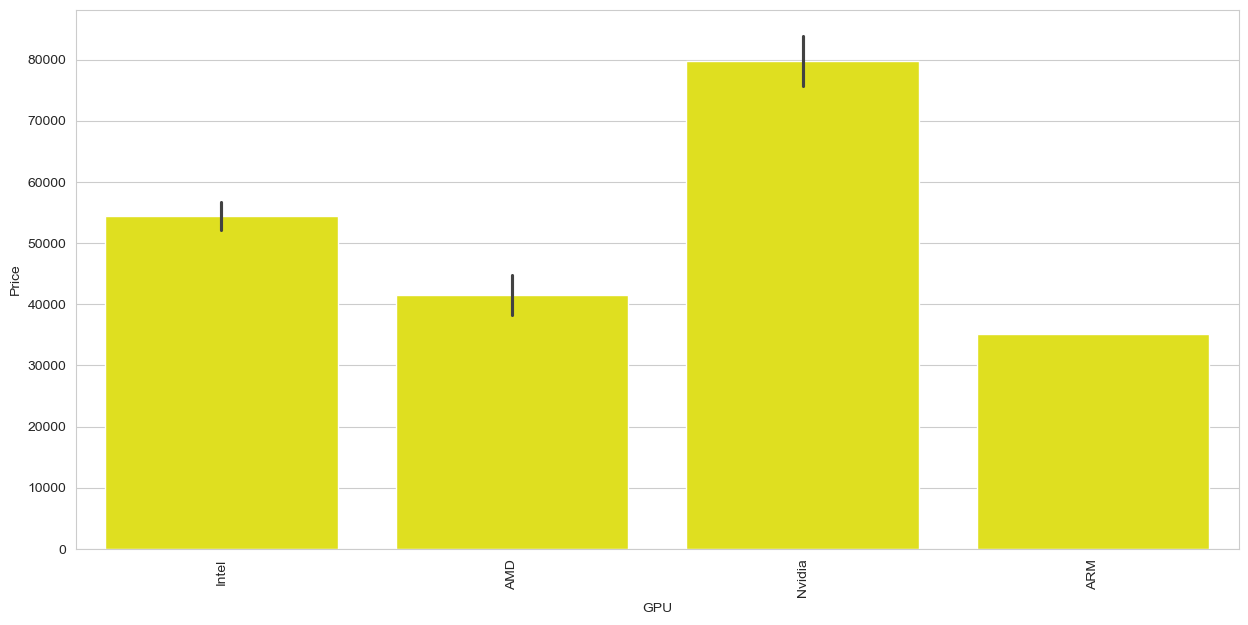

In [46]:
plt.figure(figsize=(15,7))
sns.barplot(x=df['GPU'],y=df['Price'],color='yellow')
plt.xticks(rotation= 'vertical')
plt.show()

In [ ]:
#ScreenResolution Analysis

In [47]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                505
1366x768                                         262
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         51
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x1440                    5
IPS Panel Quad HD+ / Touchscr

In [48]:
df['TouchScreen'] = df['ScreenResolution'].apply(lambda element:1 if 'Touchscreen' in element else 0)
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen
1126,Lenovo,2 in 1 Convertible,10.1,IPS Panel Touchscreen 1920x1200,4,Windows 10,0.69,25521.120,Other Intel Processor,,,Intel,1
626,Mediacom,Notebook,14.0,Full HD 1920x1080,2,Windows 10,1.40,12733.920,Other Intel Processor,,,Intel,0
1105,Dell,Ultrabook,12.5,1366x768,8,Windows 7,1.50,75289.968,Intel Core i5,,256,Intel,0
47,Asus,Gaming,17.3,Full HD 1920x1080,8,Windows 10,3.20,69210.720,AMD,1000,256,AMD,0
784,Lenovo,Ultrabook,14.0,Full HD 1920x1080,16,Windows 10,1.70,122490.720,Intel Core i7,,512,Intel,0


In [49]:
df['IPS']= df['ScreenResolution'].apply(lambda element:1 if 'IPS' in element else 0)
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS
336,Dell,Ultrabook,15.6,IPS Panel Full HD 1920x1080,8,Windows 10,1.90,55890.72,Intel Core i5,1000,128,Nvidia,0,1
658,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,8,Windows 10,3.31,63722.88,Intel Core i7,1000,128,Nvidia,0,1
386,Lenovo,Notebook,13.3,IPS Panel Full HD 1920x1080,4,Windows 10,1.50,29250.72,Intel Core i3,,128,Intel,0,1
573,Lenovo,Notebook,15.6,Full HD 1920x1080,8,Windows 10,2.30,44222.40,Intel Core i5,,256,Intel,0,0
923,Toshiba,Notebook,15.6,IPS Panel Full HD 1920x1080,16,Windows 10,2.40,105228.00,Intel Core i7,,256,Nvidia,0,1


In [50]:
splitdf = df['ScreenResolution'].str.split('x',n = 1,expand=True)
splitdf.head()

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600


In [51]:
splitdf = df['ScreenResolution'].str.split('x',n = 1,expand=True)

df['X_res'] = splitdf[0]
df['Y_res'] = splitdf[1]
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,IPS Panel Retina Display 2560,1600


In [52]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res
1263,Acer,Notebook,15.6,1366x768,4,Linux,2.40,15397.9200,Other Intel Processor,0,,Intel,0,0,1366,768
664,MSI,Gaming,17.3,Full HD 1920x1080,8,Windows 10,2.70,79215.1056,Intel Core i7,1000,128,Nvidia,0,0,Full HD 1920,1080
23,Dell,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,8,Windows 10,1.62,43636.3200,Intel Core i5,,256,Intel,1,0,Full HD / Touchscreen 1920,1080
193,Lenovo,Notebook,17.3,1600x900,8,No OS,2.80,37189.4400,Intel Core i5,,256,Nvidia,0,0,1600,900
195,HP,Notebook,17.3,IPS Panel Full HD 1920x1080,8,Windows 10,2.50,48697.9200,Intel Core i5,1000,,Nvidia,0,1,IPS Panel Full HD 1920,1080


In [53]:
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+.?\d+)').apply(lambda x:x[0])
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,2560,1600


In [54]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res
1103,HP,Workstation,17.3,IPS Panel Full HD 1920x1080,8,Windows 7,3.00,154458.7200,Intel Core i7,1000,,AMD,0,1,1920,1080
1203,Dell,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,16,Windows 10,1.20,142790.4000,Intel Core i7,,512,Intel,1,0,3200,1800
719,HP,Notebook,17.3,Full HD 1920x1080,8,Windows 10,2.63,63936.0000,Intel Core i7,,256,Nvidia,0,0,1920,1080
275,Dell,Notebook,15.6,1366x768,12,Windows 10,2.30,37992.3696,Intel Core i7,1000,,Intel,0,0,1366,768
163,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,16,Windows 10,2.50,57489.1200,Intel Core i7,,256,Nvidia,0,1,1920,1080


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Ram               1274 non-null   int32  
 5   OpSys             1274 non-null   object 
 6   Weight            1274 non-null   float32
 7   Price             1274 non-null   float64
 8   CPU               1274 non-null   object 
 9   HDD               1274 non-null   object 
 10  SSD               1274 non-null   object 
 11  GPU               1274 non-null   object 
 12  TouchScreen       1274 non-null   int64  
 13  IPS               1274 non-null   int64  
 14  X_res             1274 non-null   object 
 15  Y_res             1274 non-null   object 
dtypes: float32(1), float64(2), int32(1), int64(2), 

In [56]:
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Ram               1274 non-null   int32  
 5   OpSys             1274 non-null   object 
 6   Weight            1274 non-null   float32
 7   Price             1274 non-null   float64
 8   CPU               1274 non-null   object 
 9   HDD               1274 non-null   object 
 10  SSD               1274 non-null   object 
 11  GPU               1274 non-null   object 
 12  TouchScreen       1274 non-null   int64  
 13  IPS               1274 non-null   int64  
 14  X_res             1274 non-null   int64  
 15  Y_res             1274 non-null   int64  
dtypes: float32(1), float64(2), int32(1), int64(4), 

In [57]:
df['PPI'] = (((df['X_res']**2+df['Y_res']**2))**0.5/df['Inches']).astype('float')
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,2560,1600,226.983005


In [58]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,2560,1600,226.983005


In [59]:
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,PPI
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,226.983005
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,Intel Core i5,,,Intel,0,0,127.677940
2,HP,Notebook,8,No OS,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,141.211998
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,220.534624
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,226.983005


In [ ]:
#0S analysis

In [60]:
df['OpSys'].value_counts()

OpSys
Windows 10      1047
No OS             66
Linux             58
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

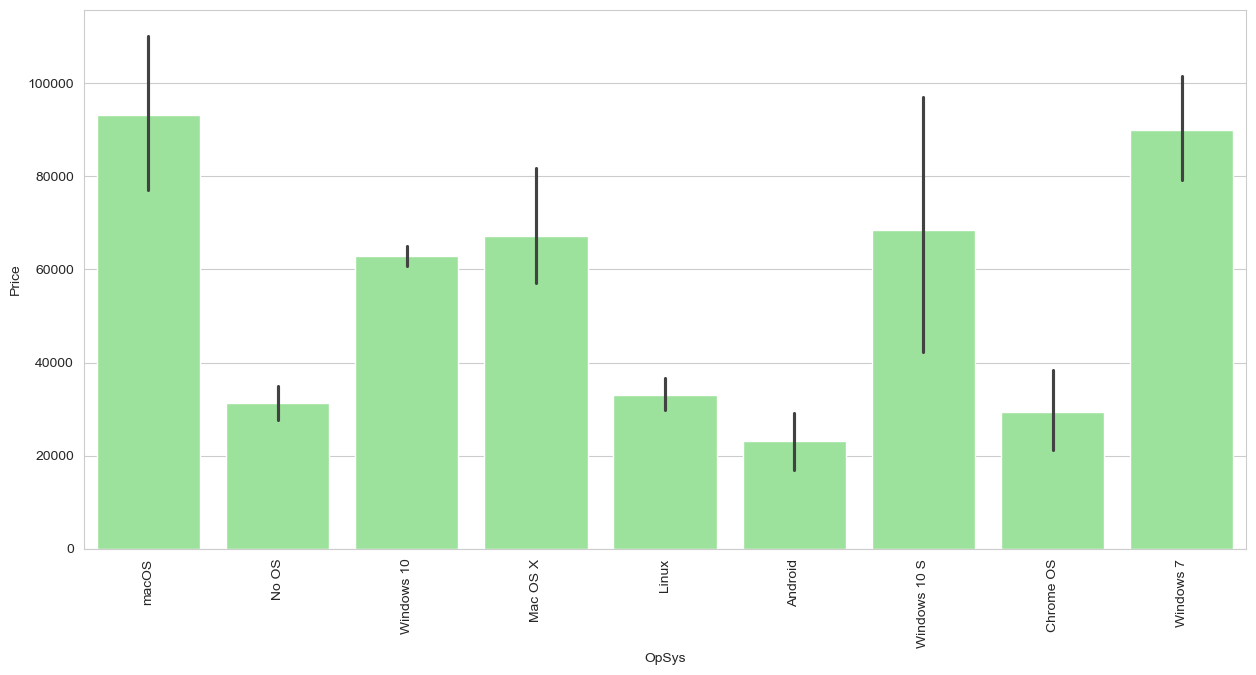

In [61]:
plt.figure(figsize=(15,7))
sns.barplot(x=df['OpSys'],y=df['Price'],color='lightgreen')
plt.xticks(rotation = 'vertical')
plt.show()

In [62]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [63]:
def setcategory(text):
    if text=='Windows 10' or text=='Windows 7' or text=='Windows 10 S':
        return 'Windows'
    elif text=='Mac OS X' or text=='macOS':
        return 'Mac'
    else:
        return 'Other'
df['OpSys'] = df['OpSys'].apply(lambda x:setcategory(x))
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,PPI
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,226.983005
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,Intel Core i5,,,Intel,0,0,127.677940
2,HP,Notebook,8,Other,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,141.211998
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,220.534624
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,226.983005


In [64]:
df.sample(5)

,Company,TypeName,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,PPI
45,Apple,Ultrabook,8,Mac,1.37,75604.3200,Intel Core i5,,256,Intel,0,1,226.983005
228,Asus,Notebook,8,Windows,2.69,47472.4800,Intel Core i5,0,256,Nvidia,0,0,127.335675
1223,Dell,Ultrabook,8,Windows,1.26,91288.3536,Intel Core i5,,256,Intel,1,0,176.232574
500,Asus,Netbook,4,Windows,1.20,18115.2000,Other Intel Processor,,,Intel,0,0,135.094211
1045,HP,Notebook,8,Windows,1.84,112065.9552,Intel Core i5,0,256,Intel,0,0,141.211998


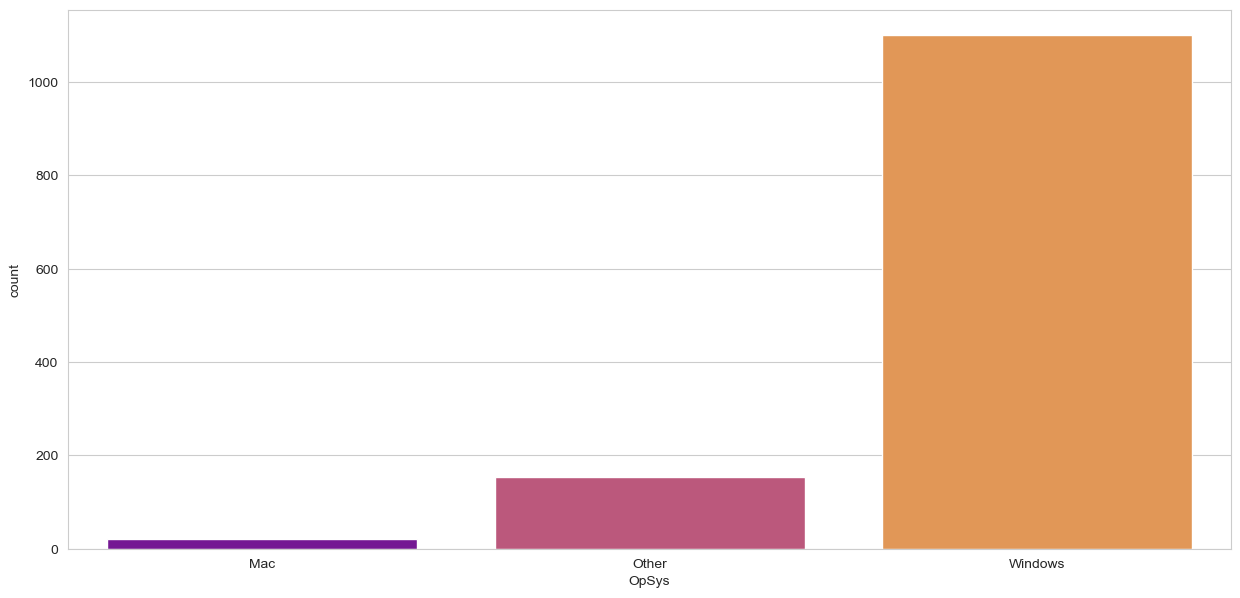

In [65]:
plt.figure(figsize=(15,7))
sns.countplot(x=df['OpSys'],hue=df['OpSys'],palette='plasma')
plt.show()

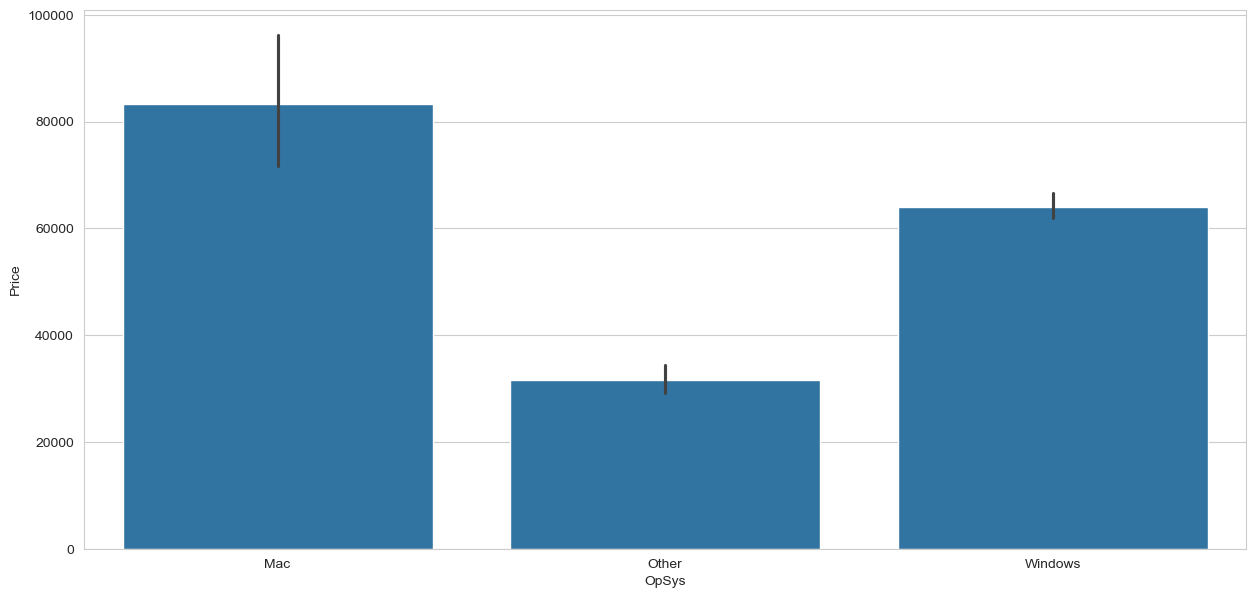

In [66]:
plt.figure(figsize=(15,7))
sns.barplot(x = df['OpSys'],y = df['Price'])
plt.show()

In [ ]:
#weight

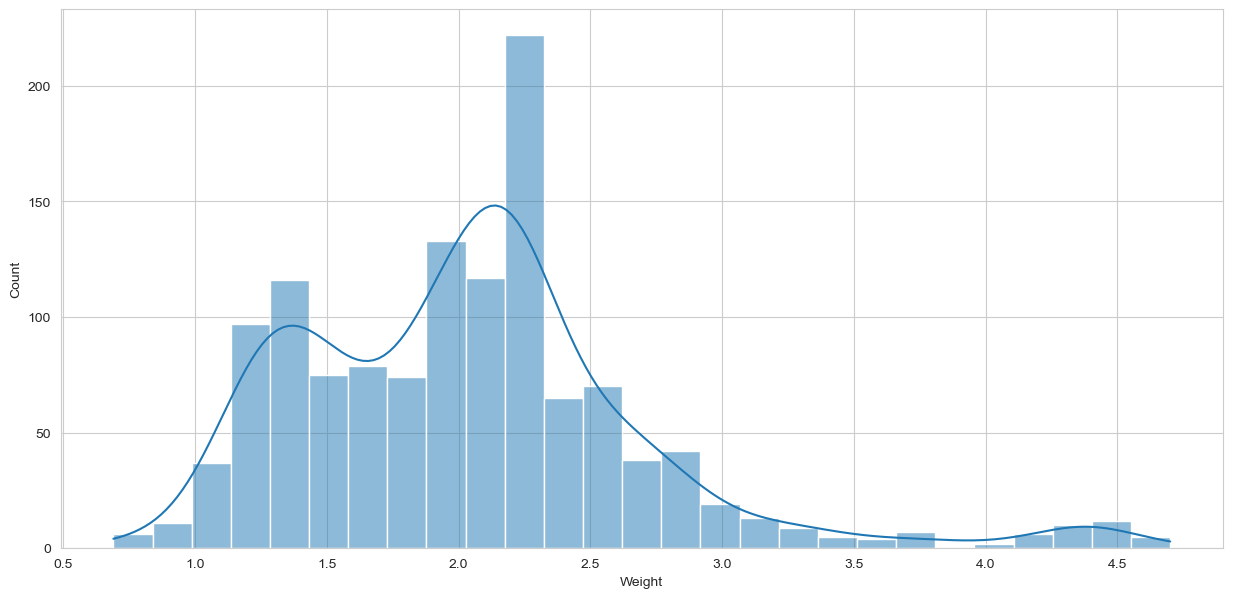

In [67]:
plt.figure(figsize=(15,7))
sns.histplot(df['Weight'],kde= True)
plt.show()

In [ ]:
# Price

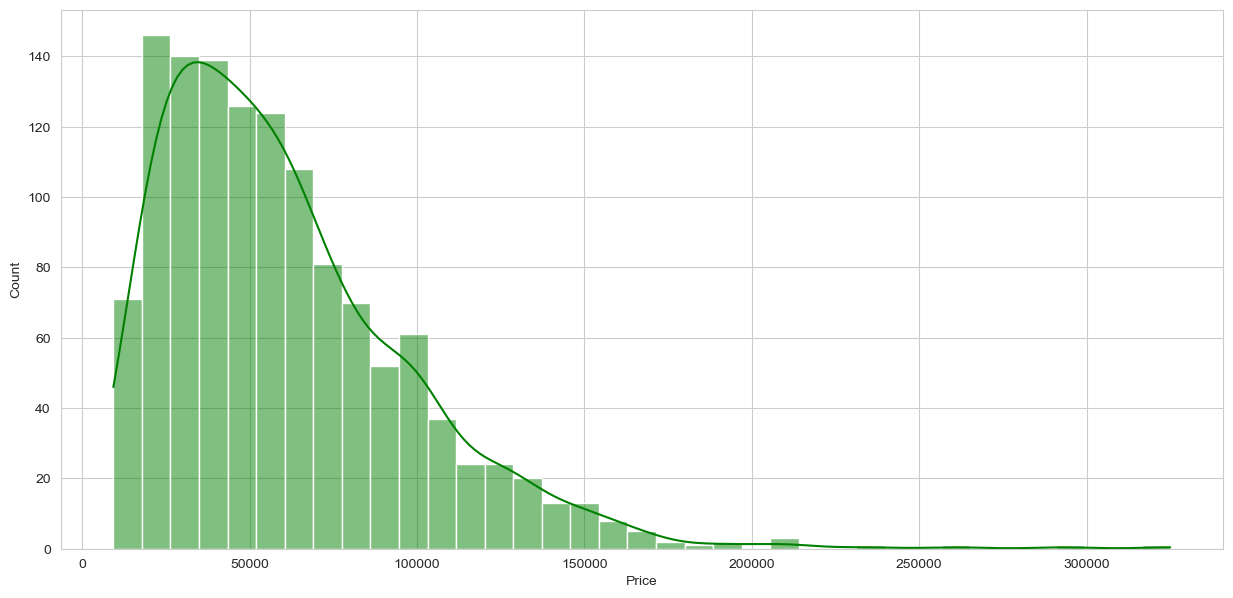

In [68]:
plt.figure(figsize=(15,7))
sns.histplot(df['Price'],color='green',kde= True)
plt.show()

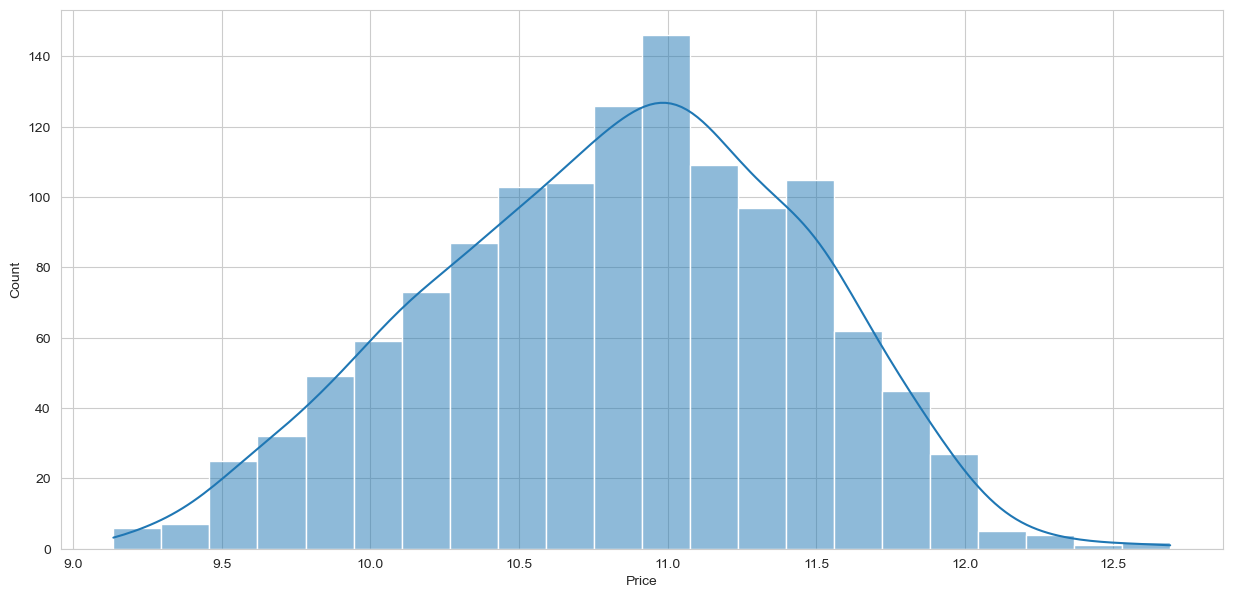

In [88]:
plt.figure(figsize=(15,7))
sns.histplot(np.log(df['Price']),kde= True)
plt.show()

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1274 non-null   object 
 1   TypeName     1274 non-null   object 
 2   Ram          1274 non-null   int32  
 3   OpSys        1274 non-null   object 
 4   Weight       1274 non-null   float32
 5   Price        1274 non-null   float64
 6   CPU          1274 non-null   object 
 7   HDD          1274 non-null   object 
 8   SSD          1274 non-null   object 
 9   GPU          1274 non-null   object 
 10  TouchScreen  1274 non-null   int64  
 11  IPS          1274 non-null   int64  
 12  PPI          1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), int64(2), object(7)
memory usage: 129.4+ KB


In [70]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,CPU,HDD,SSD,GPU,TouchScreen,IPS,PPI
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,Intel Core i5,,128,Intel,0,1,226.983005
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,Intel Core i5,,,Intel,0,0,127.677940
2,HP,Notebook,8,Other,1.86,30636.0000,Intel Core i5,,256,Intel,0,0,141.211998
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,Intel Core i7,,512,AMD,0,1,220.534624
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,Intel Core i5,,256,Intel,0,1,226.983005


In [ ]:
#train and test use KNN

In [71]:
y = np.log(df['Price'])
X = df.drop(['Price'],axis = 1)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree

In [73]:


X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.15,
                                                    random_state=2)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1082, 12) (192, 12) (1082,) (192,)


In [74]:
mapper = {i:value for i,value in enumerate(X_train.columns)}
mapper

{0: 'Company',
 1: 'TypeName',
 2: 'Ram',
 3: 'OpSys',
 4: 'Weight',
 5: 'CPU',
 6: 'HDD',
 7: 'SSD',
 8: 'GPU',
 9: 'TouchScreen',
 10: 'IPS',
 11: 'PPI'}

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1274 non-null   object 
 1   TypeName     1274 non-null   object 
 2   Ram          1274 non-null   int32  
 3   OpSys        1274 non-null   object 
 4   Weight       1274 non-null   float32
 5   Price        1274 non-null   float64
 6   CPU          1274 non-null   object 
 7   HDD          1274 non-null   object 
 8   SSD          1274 non-null   object 
 9   GPU          1274 non-null   object 
 10  TouchScreen  1274 non-null   int64  
 11  IPS          1274 non-null   int64  
 12  PPI          1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), int64(2), object(7)
memory usage: 129.4+ KB


In [76]:
df['HDD'] = pd.to_numeric(df['HDD'], errors='coerce').fillna(0).astype(float)
df= df.drop('HDD', axis=1)
df['SSD'] = pd.to_numeric(df['SSD'], errors='coerce').fillna(0).astype(float)


categorical_features_for_encoding = [
    'Company',
    'TypeName',
    'OpSys',
    'CPU',
    'GPU', 
    'HDD',
    'SSD'
]

numerical_features_for_scaling = [
    'Ram', 
    'Weight',
    'TouchScreen',
    'IPS',
    'PPI'
    

]

In [167]:
step1_preprocessor = ColumnTransformer(
    transformers=[
        ('onehot_encoder', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_features_for_encoding),
        ('scaler', StandardScaler(), numerical_features_for_scaling)
    ],
    remainder='passthrough'
)

In [168]:


step2_knn = KNeighborsRegressor(n_neighbors=5)

pipe = Pipeline([
    ('preprocessor', step1_preprocessor), 
    ('regressor', step2_knn)              
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print('R2 score', metrics.r2_score(y_test, y_pred))
print('MAE', metrics.mean_absolute_error(y_test, y_pred))

R2 score 0.8474810697155718
MAE 0.1701132605361393


In [169]:
print("X_train.columns:", X_train.columns.tolist())
print("\nX_train.dtypes:\n", X_train.dtypes)

X_train.columns: ['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'CPU', 'GPU', 'TouchScreen', 'IPS', 'HDD', 'SSD', 'PPI']

X_train.dtypes:
 Company         object
TypeName        object
Ram              int32
OpSys           object
Weight         float32
CPU             object
GPU             object
TouchScreen      int64
IPS              int64
HDD             object
SSD             object
PPI            float64
dtype: object


In [172]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [173]:
train.head()

,Company,TypeName,Ram,OpSys,Weight,CPU,GPU,TouchScreen,IPS,HDD,SSD,PPI
0,Apple,Ultrabook,8,Mac,1.37,Intel Core i5,Intel,0,1,,128,226.983005
1,Apple,Ultrabook,8,Mac,1.34,Intel Core i5,Intel,0,0,,,127.677940
2,HP,Notebook,8,Other,1.86,Intel Core i5,Intel,0,0,,256,141.211998
3,Apple,Ultrabook,16,Mac,1.83,Intel Core i7,AMD,0,1,,512,220.534624
4,Apple,Ultrabook,8,Mac,1.37,Intel Core i5,Intel,0,1,,256,226.983005


In [174]:
train.to_csv('traineddata.csv',index=None)